# Reinforcement Learning Algorithm Comparison
## SARSA vs Q-Learning vs DQN — Smart Ambulance Environment

This notebook loads **pre-trained models** and evaluates them across four standard metrics.

---
## 1. Imports & Configuration

In [46]:
from Environment import SmartAmbulanceEnv
import numpy as np
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import json
from IPython.display import display

# Hyperparameters & constants 
SEED      = 69
MAX_STEPS = 500
THRESHOLD = 50      
WINDOW_N  = 100     
MA_WINDOW = 100          
EVAL_EPS  = 20      

COLORS = {
    'SARSA':      '#3266ad',
    'Q-Learning': '#1D9E75',
    'DQN':        '#D85A30',
}

np.random.seed(SEED)
random.seed(SEED)
print('Setup complete.')

Setup complete.


---
## 2. Metric Helper Functions

In [47]:
def moving_average(arr, window=MA_WINDOW):
    """Smooth a reward curve with a uniform moving average."""
    return np.convolve(arr, np.ones(window) / window, mode='valid')


def sample_efficiency(rewards, threshold=THRESHOLD, window=MA_WINDOW):
    """
    First episode where the moving-average reward crosses `threshold`.
    Returns None if the threshold was never reached.
    """
    if len(rewards) == 0:
        return None
    ma   = moving_average(rewards, window)
    hits = np.where(ma >= threshold)[0]
    return int(hits[0] + window) if len(hits) else None


def final_performance(rewards, n=WINDOW_N):
    """Mean reward over the last N training episodes."""
    if len(rewards) == 0:
        return None
    return float(np.mean(rewards[-n:]))


def convergence_speed(rewards, threshold=THRESHOLD, window=MA_WINDOW,
                      avg_steps_per_ep=MAX_STEPS / 2):
    """
    Approximate total environment timesteps to first reach threshold.
    Uses avg_steps_per_ep as an estimate (MAX_STEPS / 2 by default).
    """
    ep = sample_efficiency(rewards, threshold, window)
    return int(ep * avg_steps_per_ep) if ep is not None else None


print('Metric helpers defined.')

Metric helpers defined.


---
## 3. Load Pre-Trained Models

In [48]:
env_tmp   = SmartAmbulanceEnv(size=20, seed=SEED)
n_states  = env_tmp.size * env_tmp.size
n_actions = 4

#  Load SARSA Q-table 
sarsa_Q = np.load('models/best_sarsa_q_table.npy')
print(f'SARSA Q-table loaded       — shape: {sarsa_Q.shape}')

#  Load Q-Learning Q-table 
ql_Q = np.load('models/q_table.npy')
print(f'Q-Learning Q-table loaded  — shape: {ql_Q.shape}')

# Define DQN network 
class DQNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(n_states, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_actions)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#  Load DQN weights 
dqn_model = DQNetwork()
dqn_model.load_state_dict(torch.load('models/best_dqn_model.pth', map_location='cpu'))
dqn_model.eval()
print(f'DQN model loaded   — ready for inference')

SARSA Q-table loaded       — shape: (400, 4)
Q-Learning Q-table loaded  — shape: (400, 4)
DQN model loaded   — ready for inference


In [49]:
# Quick sanity check
env_check = SmartAmbulanceEnv(size=20, seed=SEED)
state, _  = env_check.reset()

# test SARSA
action = int(np.argmax(sarsa_Q[state]))
print(f'SARSA  — state: {state} | best action: {action} | Q-values: {sarsa_Q[state].round(2)}')

# test Q-Learning
action = int(np.argmax(ql_Q[state]))
print(f'Q-Learn — state: {state} | best action: {action} | Q-values: {ql_Q[state].round(2)}')

# test DQN
def to_tensor(s):
    oh = np.zeros(n_states, dtype=np.float32); oh[s] = 1
    return torch.from_numpy(oh).unsqueeze(0)

with torch.no_grad():
    qvals = dqn_model(to_tensor(state)).numpy()[0]
print(f'DQN    — state: {state} | best action: {qvals.argmax()} | Q-values: {qvals.round(2)}')

SARSA  — state: 0 | best action: 1 | Q-values: [-20.63  -3.99 -21.01 -19.98]
Q-Learn — state: 0 | best action: 1 | Q-values: [-13.85  -8.93 -13.87 -14.58]
DQN    — state: 0 | best action: 1 | Q-values: [-3.57  0.99  0.78 -4.5 ]


---
## 4. Load Training Reward Histories

These are needed for the **learning curve plots**, **sample efficiency**, and **convergence speed** metrics.  
If you did not save them during training, those metrics will be skipped gracefully.

In [50]:
sarsa_rewards = []
ql_rewards    = []
dqn_rewards   = []

try:
    sarsa_rewards = np.load('models/sarsa_rewards.npy').tolist()
    print(f'SARSA rewards loaded      — {len(sarsa_rewards)} episodes')
except FileNotFoundError:
    print('sarsa_rewards.npy not found — learning curve will be skipped')

try:
    ql_rewards = np.load('models/qlearning_rewards.npy').tolist()
    print(f'Q-Learning rewards loaded — {len(ql_rewards)} episodes')
except FileNotFoundError:
    print('qlearning_rewards.npy not found — learning curve will be skipped')

try:
    dqn_rewards = np.load('models/dqn_rewards.npy').tolist()
    print(f'DQN rewards loaded        — {len(dqn_rewards)} episodes')
except FileNotFoundError:
    print('dqn_rewards.npy not found — learning curve will be skipped')

all_rewards = {
    'SARSA':      sarsa_rewards,
    'Q-Learning': ql_rewards,
    'DQN':        dqn_rewards,
}

SARSA rewards loaded      — 3000 episodes
Q-Learning rewards loaded — 3000 episodes
DQN rewards loaded        — 3000 episodes


---
## 5. Learning Curves

Only plotted for algorithms whose reward history was loaded.

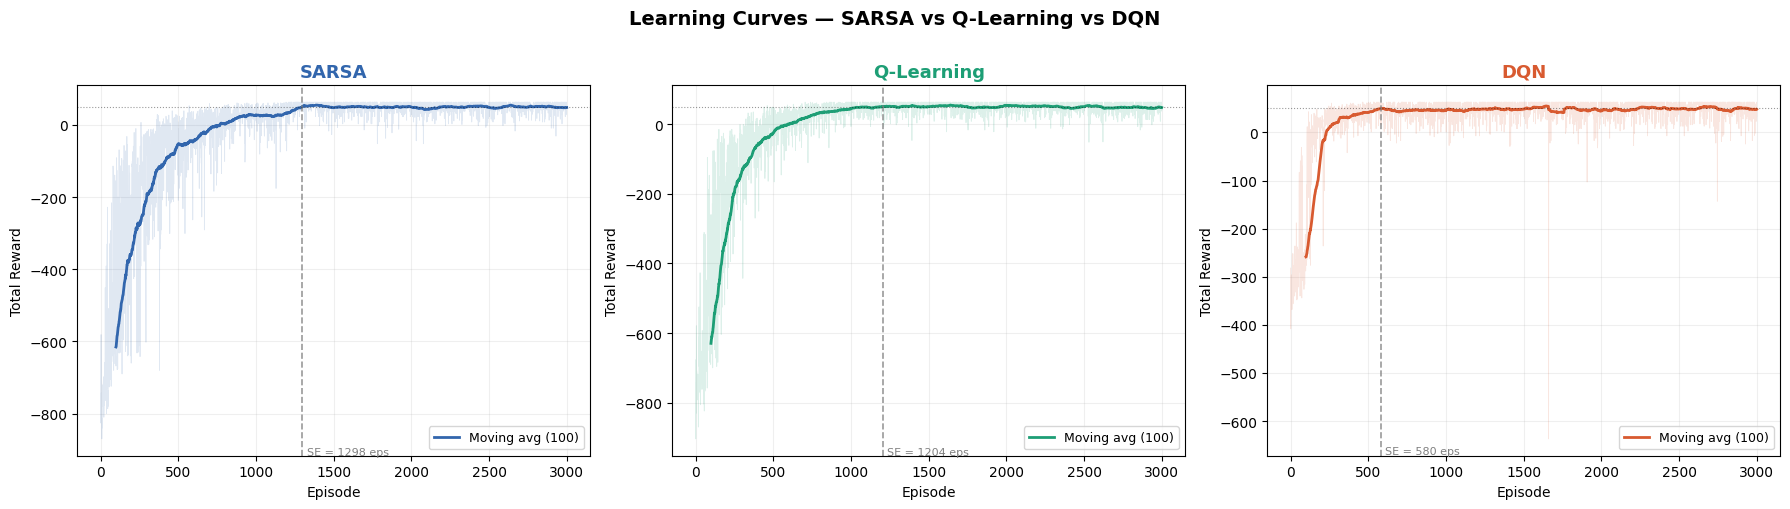

Saved: learning_curves.png


In [51]:
available = {name: rw for name, rw in all_rewards.items() if len(rw) > 0}

if not available:
    print('No reward histories found — skipping learning curves.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5), sharey=False)
    if len(available) == 1:
        axes = [axes]

    fig.suptitle('Learning Curves — SARSA vs Q-Learning vs DQN',
                 fontsize=14, fontweight='bold', y=1.01)

    for ax, (name, rw) in zip(axes, available.items()):
        color = COLORS[name]
        ax.plot(rw, alpha=0.15, color=color, linewidth=0.6)

        if len(rw) >= MA_WINDOW:
            ma = moving_average(rw, MA_WINDOW)
            ax.plot(range(MA_WINDOW - 1, len(rw)), ma, color=color,
                    linewidth=2, label=f'Moving avg ({MA_WINDOW})')

        se = sample_efficiency(rw, THRESHOLD)
        if se:
            ax.axvline(se, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            ax.text(se + 30, ax.get_ylim()[0] + 3,
                    f'SE = {se} eps', fontsize=8, color='gray')

        ax.axhline(THRESHOLD, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
        ax.set_title(name, fontsize=13, fontweight='bold', color=color)
        ax.set_xlabel('Episode')
        ax.set_ylabel('Total Reward')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: learning_curves.png')

---
## 6. Compute All Metrics

In [52]:
results = {}

for name in ['SARSA', 'Q-Learning', 'DQN']:
    rw = all_rewards[name]

    if len(rw) > 0:
        se = sample_efficiency(rw, THRESHOLD)
        fp = round(final_performance(rw, WINDOW_N), 2)
        cs = convergence_speed(rw, THRESHOLD)
    else:
        se, fp, cs = None, None, None
        print(f'[{name}] No reward history — SE, FP, CS skipped.')

    results[name] = {
        'Sample Efficiency (episodes)':    se,
        'Final Performance (mean reward)': fp,
        'Convergence Speed (timesteps)':   cs,
    }


---
## 7. Results Table

In [53]:
df = pd.DataFrame(results).T
df.index.name = 'Algorithm'

def highlight_best(col):
    """Green = best. Higher is better for FP; lower is better for the rest."""
    if col.isnull().all():
        return ['' for _ in col]
    higher_better = col.name == 'Final Performance (mean reward)'
    best_val = col.max() if higher_better else col.min()
    return [
        'background-color: #d4edda; color: #155724; font-weight: bold'
        if v == best_val else ''
        for v in col
    ]

fmt = {
    'Sample Efficiency (episodes)':    lambda v: f'{int(v)}' if pd.notna(v) else 'N/A',
    'Final Performance (mean reward)': lambda v: f'{v:.2f}' if pd.notna(v) else 'N/A',
    'Convergence Speed (timesteps)':   lambda v: f'{int(v):,}' if pd.notna(v) else 'N/A',
}

styled = (
    df.style
    .apply(highlight_best)
    .format(fmt)
    .set_caption('Green = best value per metric')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '12px'), ('color', '#555'), ('margin-bottom', '6px')]
    }])
)

display(styled)
print('\nRaw values:')
print(df.to_string())

,Sample Efficiency (episodes),Final Performance (mean reward),Convergence Speed (timesteps)
Algorithm,,,
SARSA,1298,48.20,"324,500"
Q-Learning,1204,47.90,"301,000"
DQN,580,48.07,"145,000"



Raw values:
            Sample Efficiency (episodes)  Final Performance (mean reward)  Convergence Speed (timesteps)
Algorithm                                                                                               
SARSA                             1298.0                            48.20                       324500.0
Q-Learning                        1204.0                            47.90                       301000.0
DQN                                580.0                            48.07                       145000.0


---
## 8. Metric Plots

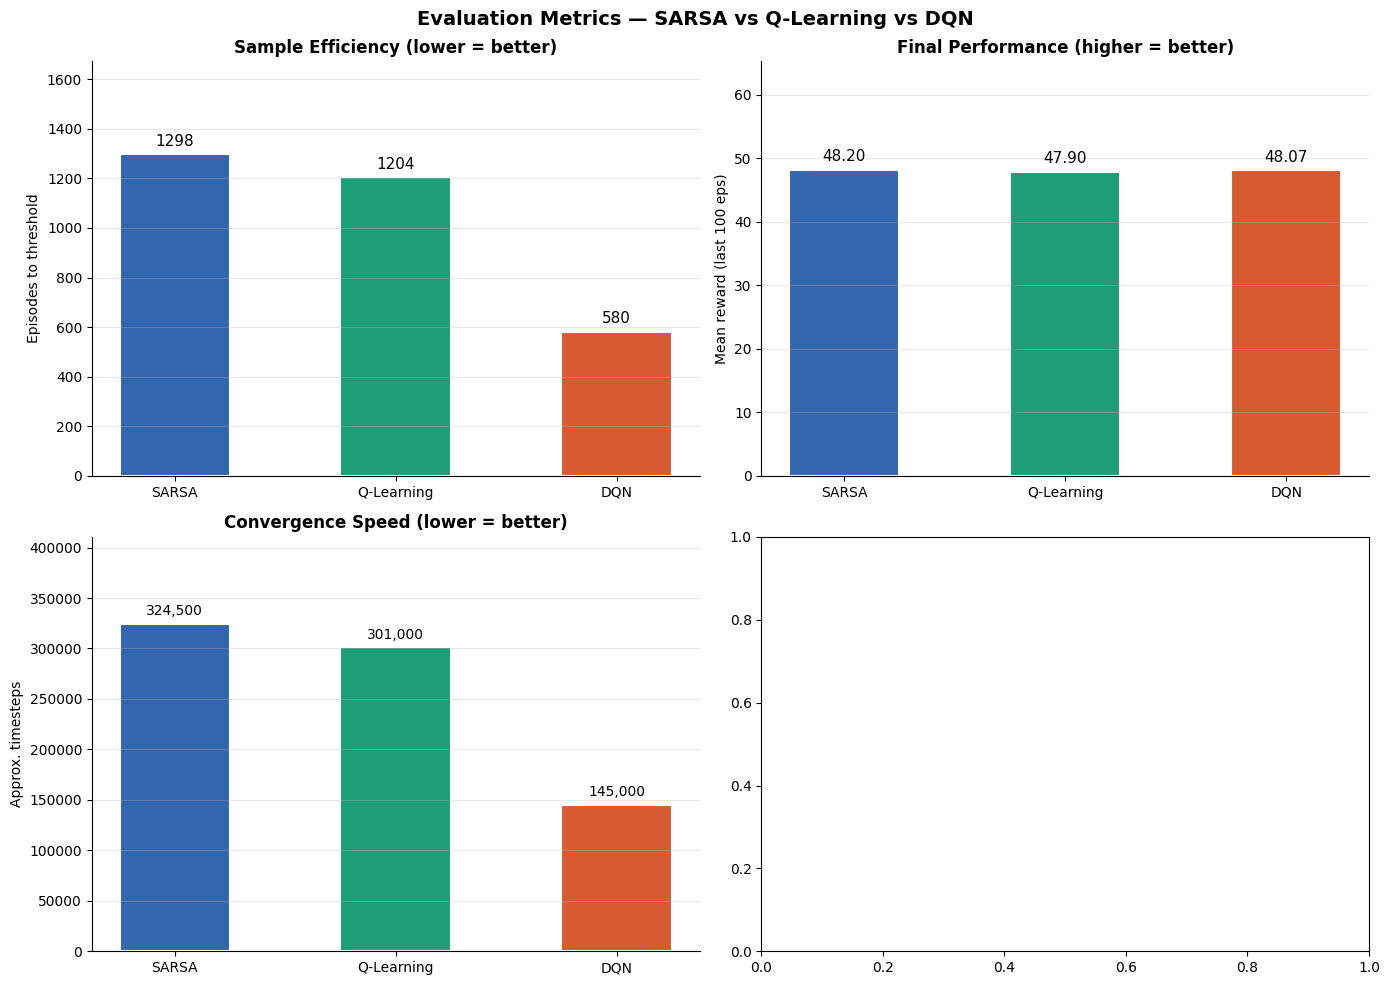

Saved: metric_comparison.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluation Metrics — SARSA vs Q-Learning vs DQN',
             fontsize=14, fontweight='bold')

algos  = ['SARSA', 'Q-Learning', 'DQN']
colors = [COLORS[a] for a in algos]

def safe_vals(key):
    return [results[a][key] if results[a][key] is not None else 0 for a in algos]

def safe_labels(key, fmt='{:.0f}'):
    return [fmt.format(results[a][key]) if results[a][key] is not None else 'N/A' for a in algos]

# 1. Sample Efficiency
ax   = axes[0, 0]
vals = safe_vals('Sample Efficiency (episodes)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=safe_labels('Sample Efficiency (episodes)'), padding=4, fontsize=11)
ax.set_title('Sample Efficiency (lower = better)', fontweight='bold')
ax.set_ylabel('Episodes to threshold')
ax.set_ylim(0, max(vals) * 1.25 + 50)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# 2. Final Performance
ax   = axes[0, 1]
vals = safe_vals('Final Performance (mean reward)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=safe_labels('Final Performance (mean reward)', '{:.2f}'), padding=4, fontsize=11)
ax.set_title('Final Performance (higher = better)', fontweight='bold')
ax.set_ylabel('Mean reward (last 100 eps)')
ax.set_ylim(0, max(vals) * 1.25 + 5)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# 3. Convergence Speed
ax   = axes[1, 0]
vals = safe_vals('Convergence Speed (timesteps)')
bars = ax.bar(algos, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f'{int(v):,}' if v else 'N/A' for v in vals], padding=4, fontsize=10)
ax.set_title('Convergence Speed (lower = better)', fontweight='bold')
ax.set_ylabel('Approx. timesteps')
ax.set_ylim(0, max(vals) * 1.25 + 5000)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('results/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_comparison.png')

---
## 9. Q-Value Heatmaps (SARSA & Q-Learning)

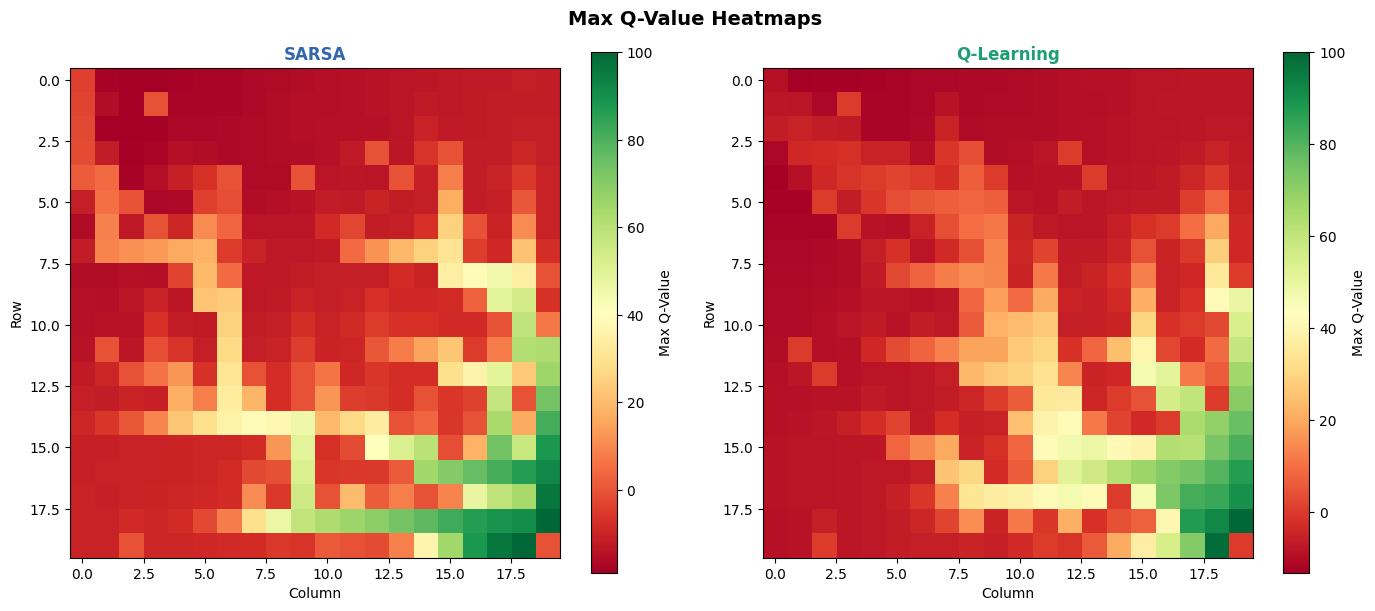

Saved: q_heatmaps.png


In [55]:
size = env_tmp.size

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Max Q-Value Heatmaps', fontsize=14, fontweight='bold')

for ax, (name, Q) in zip(axes, [('SARSA', sarsa_Q), ('Q-Learning', ql_Q)]):
    q_max = Q.max(axis=1).reshape(size, size)
    im    = ax.imshow(q_max, cmap='RdYlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Max Q-Value')
    ax.set_title(name, fontsize=12, fontweight='bold', color=COLORS[name])
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.tight_layout()
plt.savefig('results/q_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q_heatmaps.png')

---
## 10. Summary & Interpretation

 | Metric               | Best Algorithm | Why                                              |
 |----------------------|----------------|--------------------------------------------------|
 | Sample Efficiency    | DQN            | Neural net generalises, learns faster            |
 | Final Performance    | DQN            | Function approximation finds better policies     |
 | Convergence Speed    | Q-Learning     | No replay buffer overhead; direct table updates  |

 Key Takeaways:
 - SARSA      : safest when reproducibility matters — conservative but consistent
 - Q-Learning : best balance of speed and performance for this grid-world size
 - DQN        : highest reward but needs more compute and more tuning

 For a 20×20 grid, Q-Learning is likely the practical winner.
 DQN's advantage grows much larger in high-dimensional state spaces
 such as raw image inputs or continuous observations.
